`Питон` - динамически типизированный язык


*Динамически типизированный* - значит тип определяется во время работы программы, а не при ее написании или комипиляции

### Принято делить ЯП по несокльким группам


#### По способу выполнения кода:

- *Компилируемые* - специальная программа-компилятор берет весь код и переводит его в один исполняемый файл, то есть, допустим в файл `.exe` `c++, rust, go` Долгий запуск, бытсрая работа

- *Интерпретируемые* - специальная программа-интерпритатор читает код строку за стркоой прямо во время запуска и сразу выполняет его `python, php`. Быстрый запуск, медленная работа

- *Гибридные* - код-сначала компилируется в промежуточный формат, байт-код, а специальная виртуальная машина компилирует его в машинный код (JIT-компиляция). Ну и это компромис между скоростью запуска и скоростью работы программы


#### По типизации:

- *Статическая* - тип сущности известен на момент написания кода / компиляии, его надо явно задавать в коде и нельзя менять
- *Динамическая* - тип сущности становится известен во время запуска программы, переменная может менять тип


*Плюс к этому:*
- Строгая (Python) - нельзя смещивать разные типы данных (число сложить со строкой)
- Слабая (JS) - можно смешивать разные типы, язык сам пытается привести типы

#### По уровню:

- Низкоуровневые
- Высокоуровневые


#### По парадигме

- *Императивные* (C, Pascal) - код пишется как последовательность инструкций
- *ООП* - программа строится вокруг объектов
- *ФП* - программа предствляет собой цепочку математических функций, где переменная меняет свое состояния (Haskel, Scala, Elixir)

## Питон - ссылочный язык

В питоне все является ссылками, то есть если в памяти есть число 42, то переменные a и b на самом деле ссылаются на одно и тоже значение

In [ ]:
a = 42, b = 42

# Целочисленная арифметика

Сейчас в питоне нет ограничений на длину числа `int`, оно ограничивается только размером памяти компьютера, это в Python3 появилось

Типа `long` также нет, он объединен с `Int` типом

Питон числа разбивает на блоки по 30 бит, то есть по 30 символов, не по 32 потому что нужно избежать переполнения при умножении

- Например, число 2^100 хранится как массив из 4 элементов по 30 бит каждый
- Его общая память составляет 40 байт, потому что 24 байта на заголовок + 4*4 байта ~ 40 байт

В СPython реализация интового числа представлена в виде объекта, который содержит заголовок, состоящий из определенных служебных полей, которые занимают определенное количество памяти, например:

### Разбор упрощенной структуры Cpython


```python
type struct {
    PyObject_VAR_HEAD, - заголовок, примерное 24 или 28 байт
    digit ob_digit[1]; - массив цифр по 30 бит
} PyLongObject;

 ```

Размер заголовка зависит от того, какая архитектура процессора, 32 или 64, обычно на 64 битных по 28 для малых чисел используется


Любая сущность в питоне потсроена на основе `PyObject` из `C` и которая тащит за собой в памяти как минимум два поля в заголовке, а именно:

- `ob_refcnt` счетчик ссылок, если на один объект в памяти (пусть будет число 42) есть несколько ссылок, то память занята, но если вдруг это число = 0, то память освобождается 


```python
a = 42          # refcnt = 1
b = a           # refcnt = 2  
del a 
``` 


- `ob_type` указатель на тип
Благодаря этому питон динамически типизированный язык и во время выполнения он знает о типе переменнной


Для чисел добавляется еще всегда поле `ob_size`, далее из из документации:

*Он есть у объектов, которые имеют некоторое представление о длине*

Рассмотрим то, как число 0 представлено внутри памяти питона:

Памяти выделяется 32 бита, 30 под число и 2 под запас

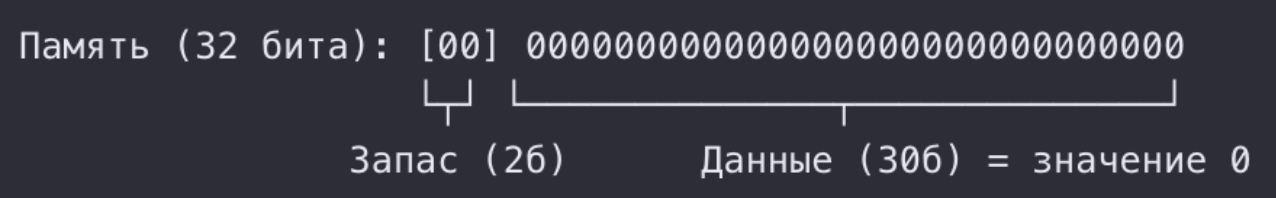

Так как само 30-битное число = 0, то `ob_size = 0`, то есть само число ничего не весит, но в объекте уже выделено 4 байта под само число и 24 под заголовки, то есть 28 байт в сумме

Теперь рассмотрим то, как число 1 представлено в памяти питона:

Памяти выделяется 32, 30 под число, 2 про запас

Но, теперь `ob_size` = 1, так как в 30 разрядах появилась единица

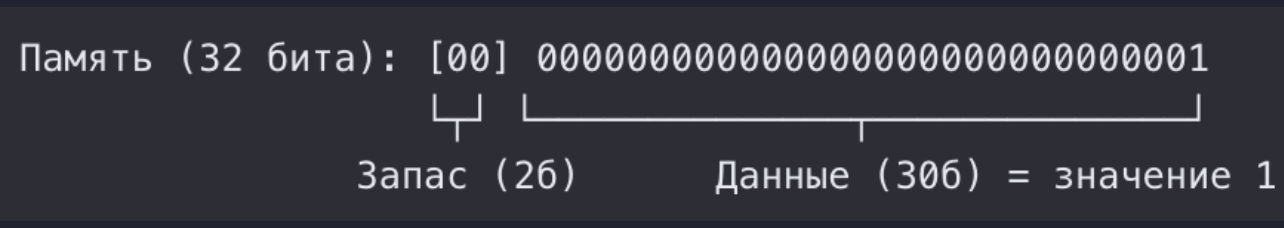

Так как само 30-битное число = 1, то `ob_size = 1`, в объекте уже выделено 4 байта под само число и 24 под заголовки, то есть 28 байт в сумме

Собственно, все числа до 2^30 - 1 будут весить по 28 байт

Для числа 2^30, которое не помещается в 28 байт, мы просто пристаиваем еще одну коробку в 4 байта (то есть 32 бита) и размерность увеличивается до 2^60 - 1

Почему под блок 4 байта? Потому что в питоне договорняк, что под разряд числа мы выделяем 32 бита, (30 на число, 2 на запас над операциями), в 32 бита влезает 4 байта (1 байт = 8 бит, их как раз помещается 4)

Подведем итоги:
- 24 байта под заголовки (при 64 разрядной архитектуре)
- 4 байта под 2^30 - 1 чисел (30 под число, 2 на длинную арифметику)
- Потом мы при переполнении, начиная с 2^30 добавялем по 4 байта под число и размер числа увеличивается до 32 байтов

# Отрицательные целые числа

В питоне то, что число отрицательное, можно узнать по все тому же полю `ob_size` у объекта. Если оно отрицательное, значит уже и само число отрицательное. Ну а дальше там применяется классическая процедура представления отрицательных чисел в памяти ПК

Получше разобрать эту тему

# Вещественные числа

# Вещественные отрицательные числа

## Операции над вещественными числами (главное вычитание)

# Строки

In [1]:
' abc '.join('123')

'1 abc 2 abc 3'

In [2]:
'123'.split('3')

['12', '']

In [3]:
a = '12 345 6 /t7 89' # в каких то версиях может пропасть символ табуляции на сплите по пустой строке ,но не в 3 10
a.split()

['12', '345', '6', '/t7', '89']

### f-строки

In [4]:
f'{10 + 30}'

'40'

In [5]:
f'{10 + 20:05d}'

'00030'

In [6]:
f'{10 + 20:05d}, {10 + 20=}'

'00030, 10 + 20=30'

In [7]:
r'\t\n\r'

'\\t\\n\\r'

In [8]:
print(r'\t\n\r123')

\t\n\r123


In [9]:
'%d + %d = %d' % (10, 20, 30)

'10 + 20 = 30'

In [10]:
'{} + {} = {}'.format(10, 20, 30)

'10 + 20 = 30'

In [11]:
f = '{} + {} = {}'
f = '{0} + {2} = {1} ({2})'
f.format(10, 20, 30)

'10 + 30 = 20 (30)'

## Списки и срезы

In [13]:
# списки - изменяемая послед элементов, в нем тип данных наз-ся ссылка
a = [1, 2, 3, 4, 5, 6]
a.append(10)

In [14]:
a.extend(a)
a

[1, 2, 3, 4, 5, 6, 10, 1, 2, 3, 4, 5, 6, 10]

In [15]:
# a[start:stop:step]
a[0:2]

[1, 2]

In [16]:

a[1:3]  = [5, 6, 7, 8]
a

[1, 5, 6, 7, 8, 4, 5, 6, 10, 1, 2, 3, 4, 5, 6, 10]

In [17]:
a + a

[1,
 5,
 6,
 7,
 8,
 4,
 5,
 6,
 10,
 1,
 2,
 3,
 4,
 5,
 6,
 10,
 1,
 5,
 6,
 7,
 8,
 4,
 5,
 6,
 10,
 1,
 2,
 3,
 4,
 5,
 6,
 10]

In [18]:
a * 3

[1,
 5,
 6,
 7,
 8,
 4,
 5,
 6,
 10,
 1,
 2,
 3,
 4,
 5,
 6,
 10,
 1,
 5,
 6,
 7,
 8,
 4,
 5,
 6,
 10,
 1,
 2,
 3,
 4,
 5,
 6,
 10,
 1,
 5,
 6,
 7,
 8,
 4,
 5,
 6,
 10,
 1,
 2,
 3,
 4,
 5,
 6,
 10]

In [19]:
a.append(a)
a
# ссылку на список положили в список

[1, 5, 6, 7, 8, 4, 5, 6, 10, 1, 2, 3, 4, 5, 6, 10, [...]]

In [20]:
a = [[1, 2]] * 3 # поменяли объект по одной и той же ссылке, список буквально явялется вектором как в плюсах почитать
a[0].append(3)
a

[[1, 2, 3], [1, 2, 3], [1, 2, 3]]

## Кортеж

Является неизменяемой структурой данных

Неизменяемой потому что хеширование на элементы и не надо ключи пересоздавать

За счет этого быстрее списка

In [21]:
# кортеж - нельзя менять
a = (1, 2, 3, 4)
a[1] = 2

TypeError: 'tuple' object does not support item assignment

In [22]:
(1)

1

In [23]:
(1,)

(1,)

## Множества

К ним нельзя обратиться по индексу

In [24]:
a = {1, 2, 3, 4, 5}

## Ассоциативный массив (коллекция)

In [25]:
a = {'a' : 1, 'b' : 2, 3: 4}
a

{'a': 1, 'b': 2, 3: 4}

Доступ можно получить только по ключу

In [26]:
a['b']

2

### Сравнение [] с {}

[] vs {} - просто более удобная абстракция, 

То есть если мы знаем заранее все элементы, то лучше использовать [], иначе лучше использовать {} если мы не знаем всех элементов

### Тип None

Под объект выделяется память в момент присваивания ему значения, а не в момент объявления

None - значит "ничего", но потом появится

Также None всегда один объект (синглтон) на весь исполняемый файл

Оператор `is` сравнивает переменные по ссылке

Оператор `==` сравние переменные по значению

Соответственно, при сравнении с None всегда надо использовать оператор is

In [27]:
a = None


type(None)() is None

True

In [32]:
список_1 = [1, 2, 3]
список_2 = [1, 2, 3]

In [33]:
список_1 == список_2

True

In [34]:
список_1 is список_2

False

### Nan

Nan - значит, что не число

Нужен чтобы показать что результат не может быть числом

Все операции с Nan привевдут к Nan резулльтату

## Циклы

In [35]:
i = 0
while i < 10:
    print(i)

    i += 1

0
1
2
3
4
5
6
7
8
9


In [36]:
for i in range(10):
    print(10)

range(10)

10
10
10
10
10
10
10
10
10
10


range(0, 10)

or i in # любой объект по которому модно итерироваться

In [37]:
for i in range(1, 10):
    if i % 2 == 0:
        print(i)

    if i % 5 == 0:
        break
# ексли ни разу не выполнился цикл
else:
    print('fo')

2
4


In [38]:
print('fdsfsd', end="")

fdsfsd

In [41]:
a = 30
print('Fizz' if a % 3 == 0 else 'Buzz' if a % 5 == 0 else 'OHNO')

Fizz


In [42]:
print('Красный\nОранжевый\nЖелтый\nЗеленый\nГолубой\nСиний\nФиолетовый')

Красный
Оранжевый
Желтый
Зеленый
Голубой
Синий
Фиолетовый


## Побитовые операции в питоне

Побитовый вывод числа

- 0b бинарный тип
- -0b отрицательыне бинарные числа

In [44]:
bin(9)

'0b1001'

In [45]:
bin(-9)

'-0b1001'

### Логическое И

Работает по таблице истинности

In [46]:
1 & 1

1

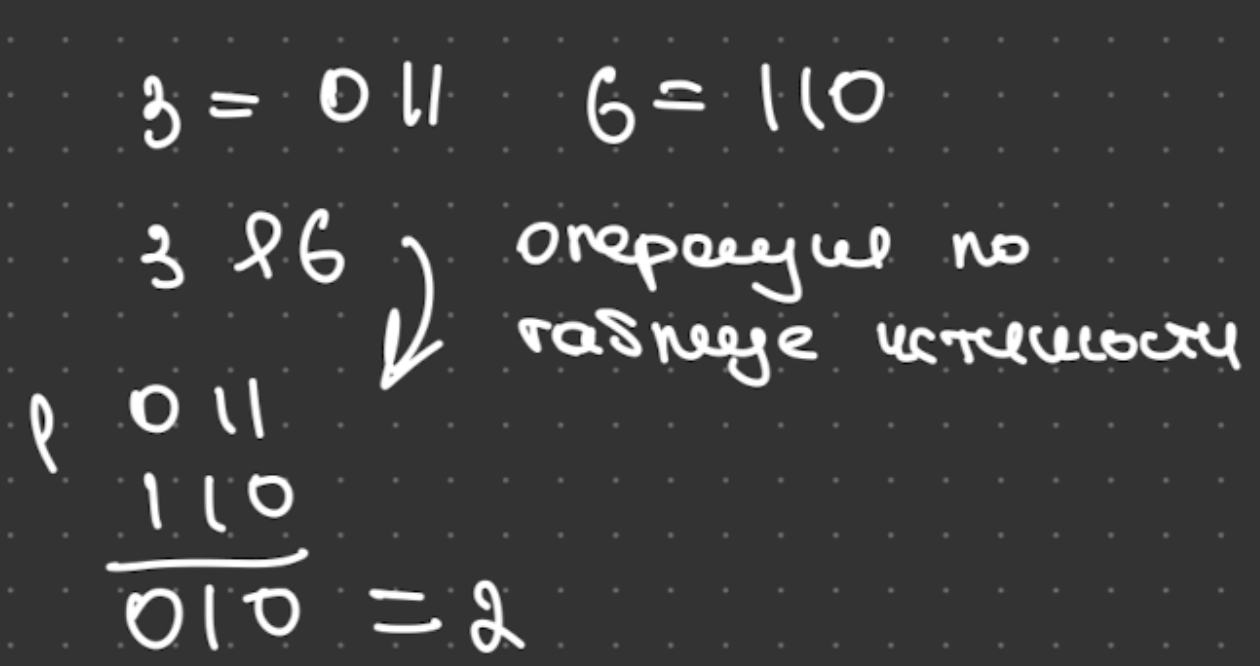

In [47]:
bin(3 & 6)

'0b10'

### Логическое ИЛИ

In [49]:
0 | 0

0

In [50]:
3 | 6 # по принципу И работет, просто побитовое сравнение

7

### XOR

- 1 - если операнды разные
- 0 - если операнды одинаковые

In [51]:
1 ^ 1

0

In [52]:
199 ^ 198

1

### ~ (not)

Работает по формуле -(x + 1)

Нужно учитывать, что положительные числа он преобразовывает в отрицательные

Комп хранит числа байтами, то есть по 8 бит, и нам надо 


Интересный факт CPython,  хранит числа инты по 30 бит, а не по 32, для того чтобы при сложении двух 30-разрядных чисел мы уложились в 64 бита, и не было переполнения, то есть можно было в СИ сохранить в long long

Операции вычитания как таковой на процессоре нет, есть операция сложения (x + y) и операция вычитания (x + (-y))

Пример: 5 - 3

5 + (-3)

Разберемся с 3, надо получить ее инверсию в битах
3 - 0000 0011
~3 - 1111 1100
~3 + 1 = 1111 1101 - это и есть -3

Теперь сложим
0000 0101 (5)
1111 1101 (-3)

1 0000 0010 - у нас получился 9 лишний бит, который процессор просто отбрасывает и получается число 2, что и является ответом на поставленную задачу

Такой подход помогает компу не уметь работать с вычитанием напрямую, а работать только через сложение, также это позволяет не возиться с -0 и +0

In [53]:
bin(-4)

'-0b100'

### Побитовые сдвиги влево и вправо

#### Сдвиг влево

Левый сдвиг можно охарактеризировать через умножение или масштабирование информации и на самом деле это является

 x * 2^n, x << n

In [54]:
1 << 1

2

единица переместилась на 1 бит влево

0000 0001 << 1

0000 0010

In [55]:
1 << 2

# 0000 00010 << 1
# 0000 0100

4

In [ ]:
2 << 3 # 2 * 2 ^ 3 = 2 * 6 = 18

16

In [58]:
3 << 2 # 3 * 2 ^ 3 = 3 * 8 = 18

12

#### Правый сдвиг

x // 2 ^ n

In [59]:

10 >> 1 # 10 // 2 = 5

5